# Analisis de eficiencia solar con PCA

Objetivo de la sesion: revisar calidad de datos, limpiar/imputar, estandarizar y aplicar PCA.

## 1) Librerias

In [1]:
!pip install pandas matplotlib seaborn scikit-learn

In [2]:
# Datos
import pandas as pd

In [3]:
# Calculo numerico
import numpy as np

In [4]:
# Graficos
import matplotlib.pyplot as plt

In [5]:
# Graficos estadisticos
import seaborn as sns

In [6]:
# Estandarizacion
from sklearn.preprocessing import StandardScaler

In [7]:
# PCA
from sklearn.decomposition import PCA

In [8]:
# Estilo de figuras
sns.set_theme(style="whitegrid")

## 2) Carga de datos

In [9]:
# Leer dataset integrado
datos = pd.read_csv("solar_efficiency.csv")

In [10]:
# Ver dimensiones
print("Filas:", datos.shape[0])
print("Columnas:", datos.shape[1])

Filas: 6417
Columnas: 24


In [11]:
# Ver nombres de variables
datos.columns.tolist()

['timestamp',
 'plant_id',
 'date',
 'hour',
 'month',
 'weekday',
 'day_of_year',
 'time_category',
 'ambient_temp',
 'module_temp',
 'irradiation',
 'temp_diff_module_ambient',
 'temp_excess',
 'irradiance_category',
 'total_dc_power',
 'total_ac_power',
 'total_daily_yield',
 'efficiency_kwh_kwp',
 'capacity_factor',
 'n_inverters',
 'yield_per_inverter',
 'dc_ac_ratio',
 'is_operating',
 'nominal_capacity']

In [12]:
# Primeras filas
datos.head()

,timestamp,plant_id,date,hour,month,weekday,day_of_year,time_category,ambient_temp,module_temp,...,total_dc_power,total_ac_power,total_daily_yield,efficiency_kwh_kwp,capacity_factor,n_inverters,yield_per_inverter,dc_ac_ratio,is_operating,nominal_capacity
0,2020-05-15T00:00:00Z,4135001,2020-05-15,0,5,Fri,136,Night_Low,25.184316,22.857507,...,0.0,0.0,0.0,0.0,0.0,21,0.0,NaN,0,50000
1,2020-05-15T00:15:00Z,4135001,2020-05-15,0,5,Fri,136,Night_Low,25.084589,22.761668,...,0.0,0.0,0.0,0.0,0.0,21,0.0,NaN,0,50000
2,2020-05-15T00:30:00Z,4135001,2020-05-15,0,5,Fri,136,Night_Low,24.935753,22.592306,...,0.0,0.0,0.0,0.0,0.0,21,0.0,NaN,0,50000
3,2020-05-15T00:45:00Z,4135001,2020-05-15,0,5,Fri,136,Night_Low,24.846130,22.360852,...,0.0,0.0,0.0,0.0,0.0,21,0.0,NaN,0,50000
4,2020-05-15T01:00:00Z,4135001,2020-05-15,1,5,Fri,136,Night_Low,24.621525,22.165423,...,0.0,0.0,0.0,0.0,0.0,22,0.0,NaN,0,50000


## 3) Calidad de datos

In [13]:
# Conteo de NA por columna
na_por_variable = datos.isna().sum().sort_values(ascending=False)
na_por_variable

dc_ac_ratio                 3007
temp_excess                    1
module_temp                    1
temp_diff_module_ambient       1
irradiance_category            0
is_operating                   0
yield_per_inverter             0
n_inverters                    0
capacity_factor                0
efficiency_kwh_kwp             0
total_daily_yield              0
total_ac_power                 0
total_dc_power                 0
timestamp                      0
plant_id                       0
irradiation                    0
ambient_temp                   0
time_category                  0
day_of_year                    0
weekday                        0
month                          0
hour                           0
date                           0
nominal_capacity               0
dtype: int64

In [14]:
# Resumen de variables clave
datos[["ambient_temp", "module_temp", "irradiation", "efficiency_kwh_kwp"]].describe()

,ambient_temp,module_temp,irradiation,efficiency_kwh_kwp
count,6417.000000,6416.000000,6417.000000,6417.000000
mean,26.834773,31.983507,0.231405,0.151167
std,3.933702,11.852631,0.307132,0.193788
min,20.398505,14.232078,0.000000,0.000000
25%,23.673325,22.467647,0.000000,0.000000
50%,25.976375,26.487864,0.023538,0.016290
75%,29.364376,40.932470,0.445260,0.315171
max,39.181638,66.635953,1.221652,0.865992


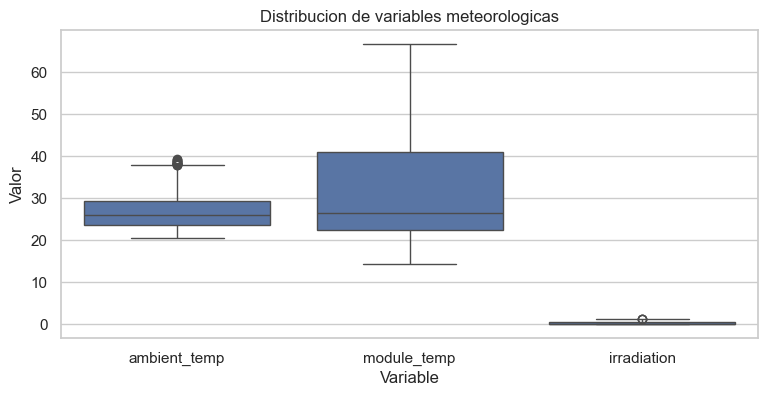

In [15]:
# Boxplots de variables meteorologicas
temp = datos[["ambient_temp", "module_temp", "irradiation"]].melt(var_name="variable", value_name="valor")
plt.figure(figsize=(9, 4))
sns.boxplot(data=temp, x="variable", y="valor")
plt.title("Distribucion de variables meteorologicas")
plt.xlabel("Variable")
plt.ylabel("Valor")
plt.show()

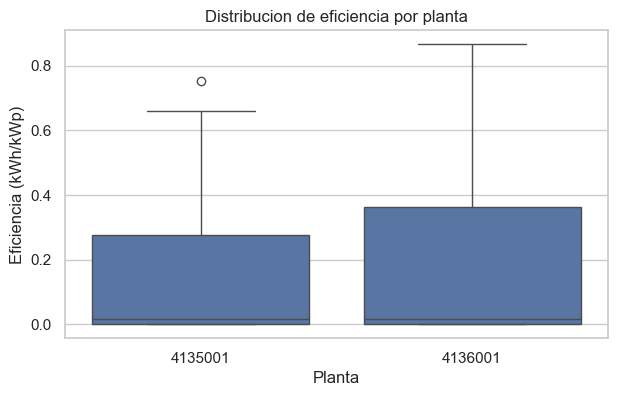

In [16]:
# Boxplot de eficiencia por planta
plt.figure(figsize=(7, 4))
sns.boxplot(data=datos, x=datos["plant_id"].astype(str), y="efficiency_kwh_kwp")
plt.title("Distribucion de eficiencia por planta")
plt.xlabel("Planta")
plt.ylabel("Eficiencia (kWh/kWp)")
plt.show()

## 4) Seleccionar variables para PCA

In [17]:
# Variables continuas relevantes
variables_pca = datos[["ambient_temp", "module_temp", "irradiation", "temp_diff_module_ambient", "temp_excess", "efficiency_kwh_kwp"]].copy()

In [18]:
# Revisar faltantes en este subconjunto
variables_pca.isna().sum()

ambient_temp                0
module_temp                 1
irradiation                 0
temp_diff_module_ambient    1
temp_excess                 1
efficiency_kwh_kwp          0
dtype: int64

## 5) Imputacion y recálculo de variables derivadas

In [19]:
# Media para temperatura ambiente
media_ambient = variables_pca["ambient_temp"].mean()

In [20]:
# Media para temperatura de modulo
media_module = variables_pca["module_temp"].mean()

In [21]:
# Imputar ambient_temp
variables_pca["ambient_temp"] = np.where(variables_pca["ambient_temp"].isna(), media_ambient, variables_pca["ambient_temp"])

In [22]:
# Imputar module_temp
variables_pca["module_temp"] = np.where(variables_pca["module_temp"].isna(), media_module, variables_pca["module_temp"])

In [23]:
# Imputar irradiacion con 0
variables_pca["irradiation"] = np.where(variables_pca["irradiation"].isna(), 0, variables_pca["irradiation"])

In [24]:
# Recalcular diferencia modulo - ambiente
variables_pca["temp_diff_module_ambient"] = variables_pca["module_temp"] - variables_pca["ambient_temp"]

In [25]:
# Recalcular exceso de temperatura sobre 40
variables_pca["temp_excess"] = np.maximum(0, variables_pca["module_temp"] - 40)

In [26]:
# Revisar faltantes tras imputar
variables_pca.isna().sum()

ambient_temp                0
module_temp                 0
irradiation                 0
temp_diff_module_ambient    0
temp_excess                 0
efficiency_kwh_kwp          0
dtype: int64

In [27]:
# Eliminar filas con NA residual
variables_pca_final = variables_pca.dropna()

In [28]:
# Ver dimensiones finales
variables_pca_final.shape

(6417, 6)

## 6) Estandarizar variables

In [29]:
# Usar solo variables independientes
X = variables_pca_final[["ambient_temp", "module_temp", "irradiation", "temp_diff_module_ambient", "temp_excess"]].copy()

In [30]:
# Ajustar estandarizador
scaler = StandardScaler()

In [31]:
# Transformar
X_scaled = scaler.fit_transform(X)

In [32]:
# Ver ejemplo de datos estandarizados
pd.DataFrame(X_scaled, columns=X.columns).head()

,ambient_temp,module_temp,irradiation,temp_diff_module_ambient,temp_excess
0,-0.419601,-0.770076,-0.753497,-0.837447,-0.485568
1,-0.444955,-0.778163,-0.753497,-0.837012,-0.485568
2,-0.482794,-0.792454,-0.753497,-0.839311,-0.485568
3,-0.505579,-0.811985,-0.753497,-0.855200,-0.485568
4,-0.562681,-0.828476,-0.753497,-0.851931,-0.485568


## 7) Aplicar PCA

In [33]:
# Crear modelo
pca = PCA()

In [34]:
# Ajustar modelo
pca.fit(X_scaled)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

In [35]:
# Varianza explicada por componente
varianza = pca.explained_variance_ratio_ * 100
varianza

array([8.62817498e+01, 9.35570360e+00, 3.73254682e+00, 6.29999808e-01,
       5.70865439e-15])

In [36]:
# Varianza acumulada
np.cumsum(varianza)

array([ 86.28174977,  95.63745337,  99.37000019, 100.        ,
       100.        ])

## 8) Scree plot

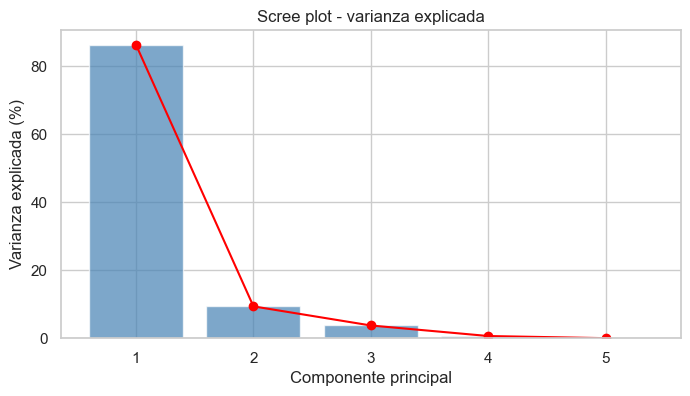

In [37]:
# Grafico de varianza explicada
componentes = np.arange(1, len(varianza) + 1)
plt.figure(figsize=(8, 4))
plt.bar(componentes, varianza, alpha=0.7, color="steelblue")
plt.plot(componentes, varianza, color="red", marker="o")
plt.title("Scree plot - varianza explicada")
plt.xlabel("Componente principal")
plt.ylabel("Varianza explicada (%)")
plt.show()

## 9) Cargas de variables (loadings)

In [38]:
# Matriz de cargas
loadings = pd.DataFrame(pca.components_.T, index=X.columns, columns=["PC1", "PC2", "PC3", "PC4", "PC5"])

In [39]:
# Ver loadings redondeados
loadings.round(3)

,PC1,PC2,PC3,PC4,PC5
ambient_temp,0.384,0.880,0.043,0.100,-0.256
module_temp,0.478,0.067,-0.191,-0.366,0.772
irradiation,0.462,-0.269,-0.382,0.754,-0.000
temp_diff_module_ambient,0.466,-0.299,-0.273,-0.530,-0.582
temp_excess,0.440,-0.243,0.861,0.080,-0.000


In [40]:
# Variable con mayor aporte absoluto en PC1
loadings["PC1"].abs().sort_values(ascending=False)

module_temp                 0.478277
temp_diff_module_ambient    0.465649
irradiation                 0.462071
temp_excess                 0.439642
ambient_temp                0.384224
Name: PC1, dtype: float64

## 10) Biplot simple (PC1 vs PC2)

In [41]:
# Proyecciones de observaciones
scores = pca.transform(X_scaled)
scores_df = pd.DataFrame(scores, columns=["PC1", "PC2", "PC3", "PC4", "PC5"])

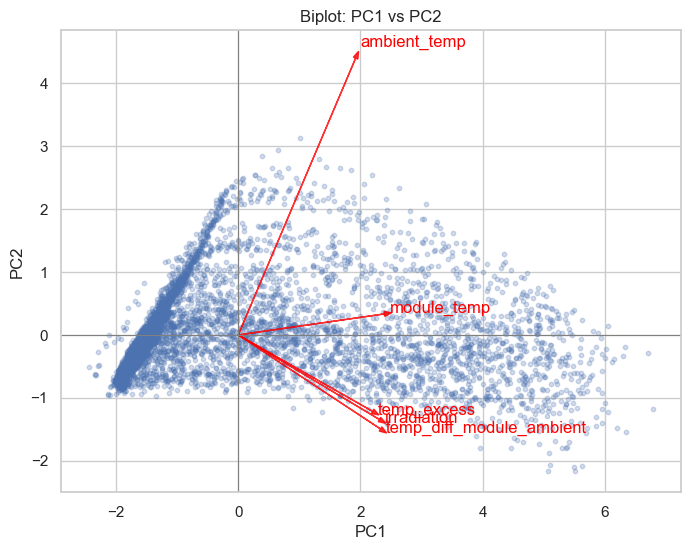

In [42]:
# Biplot basico: puntos + flechas de variables
plt.figure(figsize=(8, 6))
plt.scatter(scores_df["PC1"], scores_df["PC2"], alpha=0.25, s=10)
for i in range(len(X.columns)):
    plt.arrow(0, 0, loadings.iloc[i, 0] * 5, loadings.iloc[i, 1] * 5, color="red", head_width=0.08, alpha=0.8)
    plt.text(loadings.iloc[i, 0] * 5.2, loadings.iloc[i, 1] * 5.2, X.columns[i], color="red")
plt.axhline(0, color="gray", linewidth=0.8)
plt.axvline(0, color="gray", linewidth=0.8)
plt.title("Biplot: PC1 vs PC2")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

## 11) Cierre

In [43]:
# Resumen de resultados clave
print("Varianza explicada PC1:", round(varianza[0], 2), "%")
print("Varianza explicada PC2:", round(varianza[1], 2), "%")
print("Varianza acumulada PC1+PC2:", round(varianza[0] + varianza[1], 2), "%")

Varianza explicada PC1: 86.28 %
Varianza explicada PC2: 9.36 %
Varianza acumulada PC1+PC2: 95.64 %
